In [1]:

import pandas as pd
from joypy import joyplot
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/data/all_peter_plot_U.csv",sep=';')
df

,timepoint,replicates,length,Strains,U
0,E16.5,1,19,WSB_EiJ,0.000000
1,E16.5,1,20,WSB_EiJ,0.001460
2,E16.5,1,21,WSB_EiJ,0.001292
3,E16.5,1,22,WSB_EiJ,0.003110
4,E16.5,1,23,WSB_EiJ,0.004579
...,...,...,...,...,...
2569,P20.5,3,32,C57BL_6NJ,0.036062
2570,P20.5,3,33,C57BL_6NJ,0.006735
2571,P20.5,3,34,C57BL_6NJ,0.001584
2572,P20.5,3,35,C57BL_6NJ,0.000948


In [7]:
# Define desired order of categories
strain_order = ['C57BL_6NJ', 'BALB_cJ','A_J','FVB_NJ',   'C3H_HeJ' ,'LP_J','129S1_SvImJ' ,'DBA_2J', 'AKR_J','CBA_J','NZO_HlLtJ',  'NOD_ShiLtJ' ,'WSB_EiJ' ,'CAST_EiJ','PWK_PhJ' ,'SPRET_EiJ' ]

# Create custom categorical data type with desired order
strain_dtype = pd.api.types.CategoricalDtype(categories=strain_order, ordered=True)


# Define desired order of categories
time_order = ['E16.5','P12.5','P20.5']

# Create custom categorical data type with desired order
time_dtype = pd.api.types.CategoricalDtype(categories=time_order, ordered=True)
# Convert the day column to the custom categorical data type
df['timepoint'] = df['timepoint'].astype(time_dtype)
df['Strains'] = df['Strains'].astype(strain_dtype)

In [11]:

# Calculating mean on groupby

df['avgU'] = df.groupby(['Strains', 'timepoint', 'length'])['U'].transform('mean').reset_index(drop=True)
df


,timepoint,replicates,length,Strains,U,avgU
0,E16.5,1,19,WSB_EiJ,0.000000,0.000000
1,E16.5,1,20,WSB_EiJ,0.001460,0.001483
2,E16.5,1,21,WSB_EiJ,0.001292,0.001267
3,E16.5,1,22,WSB_EiJ,0.003110,0.002766
4,E16.5,1,23,WSB_EiJ,0.004579,0.004122
...,...,...,...,...,...,...
2569,P20.5,3,32,C57BL_6NJ,0.036062,0.035394
2570,P20.5,3,33,C57BL_6NJ,0.006735,0.006720
2571,P20.5,3,34,C57BL_6NJ,0.001584,0.001615
2572,P20.5,3,35,C57BL_6NJ,0.000948,0.000874


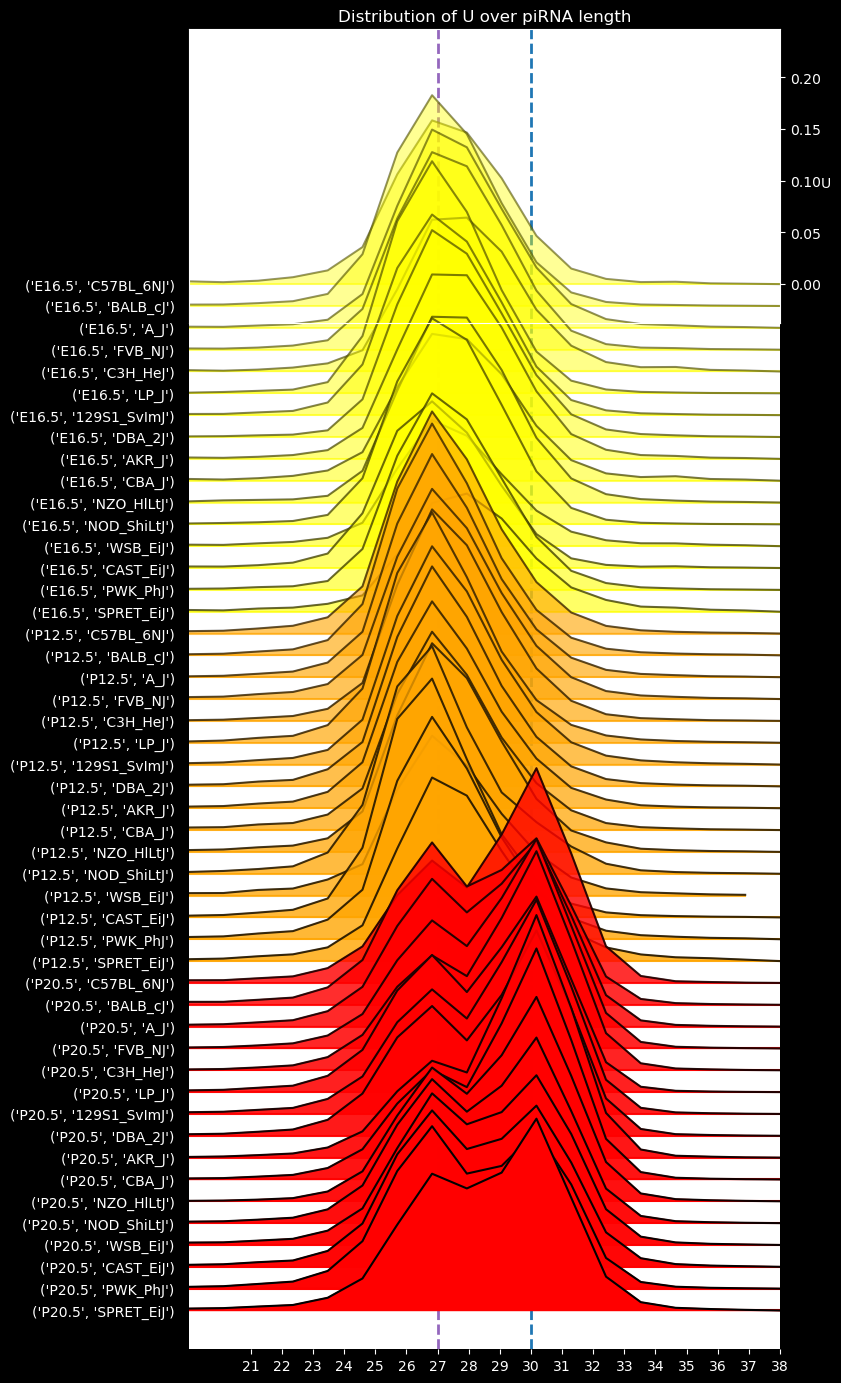

In [19]:
from matplotlib import cm, colors
import matplotlib.pyplot as plt
from  matplotlib.ticker import FuncFormatter
import numpy as np

plt.rcParams['axes.facecolor'] = 'white'
#labels=[y if y%10==0 else None for y in list(temp.Year.unique())]
#df = df.sort_values(['timpepoint', 'strains.1'],ascending = [True, False])
# Original color dictionary
colors_dict = dict(zip(unique_timpepoints, ['#FFFF00', 'orange', 'red']))

# Adjusting the colors to have some transparency
alpha = 0.9  # Adjust as needed
colors_dict_transparent = {key: colors.to_rgba(value, alpha) for key, value in colors_dict.items()}

# create a dictionary that maps each unique timpepoint value to a unique color
unique_timpepoints = df['timepoint'].unique()
n_timpepoints = len(unique_timpepoints)
colors_dict = dict(zip(unique_timpepoints, ['#FFFF00', 'orange', 'red']))


fig, axes =  joyplot(df, by = ['timepoint','Strains'],kind='values',column = 'avgU', x_range= df['length'] ,normalize=False,
        colormap=colors.ListedColormap([colors_dict_transparent[t] for t in unique_timpepoints]), 
        fade = True,range_style='all', figsize = (8,14),overlap=4,title="Distribution of U over piRNA length",bins=80,ylim='max')



xtick = df['length'].unique() +2
plt.xticks( xtick )
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))


plt.axvline(x=27, color='tab:purple', label='27', ls='--', lw=2)
plt.axvline(x=30, color='tab:blue', label='30', ls='--', lw=2)

# create a new twin axis for the top plot
ax_top = axes[0].twinx()

# plot the data on the top axis
ax_top.plot(df['length'], df['avgU'], color='black', alpha=0)

# set the y-axis label for the top axis
ax_top.set_ylabel('U', fontsize=10)
ax_top.yaxis.get_label().set_rotation(360)
# get x-axis and y-axis limits of axes[0]
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# set x-axis and y-axis limits of ax_top
ax_top.set_xlim(xlim)
ax_top.set_ylim(ylim)
# set the y-axis limits for the top axis based on the range of df[avgU']
#ax_top.set_ylim(df['U'].min())

# hide the x-axis label for the top axis
ax_top.xaxis.set_visible(False)


plt.savefig("ridge_plot_U.pdf", format='pdf', bbox_inches='tight')
plt.show()